In [1]:
from astropy.io import fits
import numpy as np
from matplotlib import pyplot as plt
import aplpy
from astropy.wcs import WCS

import sys
sys.path.append("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/process_tools")
from cut_resize_tools import convolve_vaxis, picking, gaussian_filter

In [2]:
cygnus_fits_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/NRO45m/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_Tmb.fits"
hdu = fits.open(cygnus_fits_path)[0]
raw_d = hdu.data
header = hdu.header

In [3]:
def v2ch(v, w): # v(km/s)をchに変える
    x_tempo, y_tempo, v_tempo   = w.wcs_pix2world(0, 0, 0, 0)
    x_ch, y_ch, v_ch   = w.wcs_world2pix(x_tempo, y_tempo, v*1000.0, 0)
    v_ch = int(round(float(v_ch), 0))
    return v_ch

def del_header_key(header, keys): # headerのkeyを消す
    import copy
    h = copy.deepcopy(header)
    for k in keys:
        try:
            del h[k]
        except:
            pass
    return h

def make_new_hdu_peak(hdu, v_start_wcs, v_end_wcs, w): # 積分強度のhduを作る
    data = hdu.data
    header = hdu.header
    start_ch, end_ch = v2ch(v_start_wcs, w), v2ch(v_end_wcs, w)
    new_data = np.nanmax(data[start_ch:end_ch+1], axis=0)
    header = del_header_key(header, ["CRVAL3", "CRPIX3", "CRVAL3", "CDELT3", "CUNIT3", "CTYPE3", "CROTA3", "NAXIS3", "PC1_3", "PC2_3", "PC3_3", "PC3_1", "PC3_2"])
    header["NAXIS"] = 2
    new_hdu = fits.PrimaryHDU(new_data, header)
    return new_hdu

In [4]:
vsmooth = 5
thresh = 1
sigma = 2
sch_rms = 10
ech_rms = 90
sch_ii = 121
ech_ii = 241

In [5]:
_data = raw_d.copy()
vconv = convolve_vaxis(_data, vsmooth)
_mask = vconv.copy()
rms = np.nanstd(vconv[sch_rms:ech_rms], axis=0)
_mask[np.where(_mask < rms*sigma)] = 0
ndata, _ = picking(_mask, _data, thresh)

/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
smooth_num = 3
for i in range(smooth_num):
    ndata = gaussian_filter(ndata)

In [7]:
integ_per_channel = np.nansum(ndata, axis=(1, 2))
max_channel = np.argmax(integ_per_channel)
print(max_channel)

154


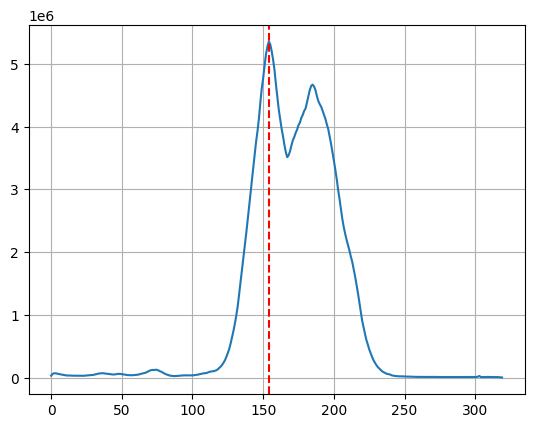

In [8]:
plt.plot(range(len(integ_per_channel)),integ_per_channel)
plt.axvline(x=max_channel, color='red', linestyle='--', label=f'channel = {max_channel}')
plt.grid()
plt.show()

In [9]:
new_header = del_header_key(header, ["CRVAL3", "CRPIX3", "CRVAL3", "CDELT3", "CUNIT3", "CTYPE3", "CROTA3", "NAXIS3", "PC1_3", "PC2_3", "PC3_3", "PC3_1", "PC3_2"])
new_header["NAXIS"] = 2
new_hdu = fits.PrimaryHDU(ndata[max_channel], new_header)

0.04092556027512396
INFO: Auto-setting vmin to -2.237e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.482e+01 [aplpy.core]


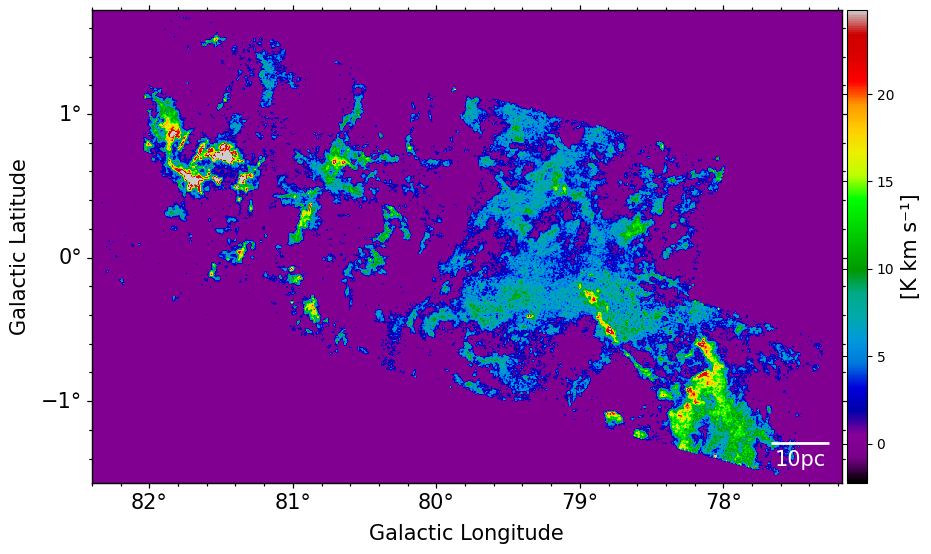

In [10]:
gc_distance = 1400
scale_per_pc = np.rad2deg(np.arcsin(1/gc_distance))
print(scale_per_pc)

fig=aplpy.FITSFigure(new_hdu)

fig.show_colorscale(cmap="nipy_spectral", stretch='linear')
fig.set_nan_color("black")
fig.add_colorbar()
fig.colorbar.set_location('right')
fig.colorbar.set_axis_label_text("[K km s⁻¹]")
fig.colorbar.set_axis_label_font(size=15)

# fig.tick_labels.set_xformat("dd.d")
fig.tick_labels.set_font(size=15) 
fig.ticks.set_color("black")
fig.axis_labels.set_font(size=15)

fig.add_scalebar(scale_per_pc*10) # スケールバーの長さ（単位は座標系に依存）
fig.scalebar.set_label('10pc')
fig.scalebar.set_color('w')
fig.scalebar.set_linewidth(2)
fig.scalebar.set_font(size=15) 

In [12]:
new_hdu.writeto("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_tpeak.fits", overwrite=True)